In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

img_size = 224
batch_size = 32


train_dir = r"D:\python\deep learnig\brain tumer\dataset\Training"
val_dir   = r"D:\python\deep learnig\brain tumer\dataset\Testing"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [7]:
from tensorflow.keras.applications import ResNet50

def build_model(base_model):

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [8]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = build_model(base_model)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [9]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 632s 3s/step - accuracy: 0.4996 - loss: 1.1140 - val_accuracy: 0.4313 - val_loss: 1.3138 - learning_rate: 1.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 462s 3s/step - accuracy: 0.5750 - loss: 0.9904 - val_accuracy: 0.5981 - val_loss: 1.1295 - learning_rate: 1.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 467s 3s/step - accuracy: 0.5914 - loss: 0.9533 - val_accuracy: 0.6394 - val_loss: 1.0884 - learning_rate: 1.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 445s 3s/step - accuracy: 0.6116 - loss: 0.9247 - val_accuracy: 0.6375 - val_loss: 1.1194 - learning_rate: 1.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 455s 3s/step - accuracy: 0.6164 - loss: 0.9103 - val_accuracy: 0.6600 - val_loss: 1.0896 - learning_rate: 1.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 3234s 18s/step - accuracy: 0.6129 - loss: 0.8995 - val_accuracy: 0.6712 - val_loss: 1.0736 - learning_rate: 1.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - a

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 545s 3s/step - accuracy: 0.5366 - loss: 1.2517 - val_accuracy: 0.3469 - val_loss: 2.6625
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 541s 3s/step - accuracy: 0.5873 - loss: 1.0274 - val_accuracy: 0.4581 - val_loss: 1.5434
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 680s 4s/step - accuracy: 0.6161 - loss: 0.9463 - val_accuracy: 0.6900 - val_loss: 1.2437
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 540s 3s/step - accuracy: 0.6336 - loss: 0.8991 - val_accuracy: 0.6825 - val_loss: 1.2451
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 43693s 251s/step - accuracy: 0.6463 - loss: 0.8719 - val_accuracy: 0.6900 - val_loss: 1.3135
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 748s 4s/step - accuracy: 0.6620 - loss: 0.8416 - val_accuracy: 0.6881 - val_loss: 1.2245
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 639s 4s/step - accuracy: 0.6652 - loss: 0.8312 - val_accuracy: 0.7100 - val_loss: 1.2074
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.6725 - loss: 0.8025 - val_

In [13]:
val_gen.reset()

pred = model.predict(val_gen)

y_pred = np.argmax(pred, axis=1)

print(classification_report(val_gen.classes, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step
              precision    recall  f1-score   support

           0       0.82      0.40      0.53       400
           1       0.64      0.45      0.53       400
           2       0.74      0.96      0.84       400
           3       0.65      0.98      0.78       400

    accuracy                           0.70      1600
   macro avg       0.71      0.70      0.67      1600
weighted avg       0.71      0.70      0.67      1600



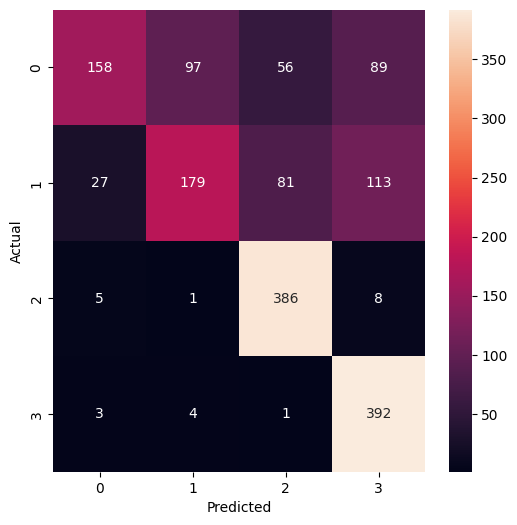

In [14]:
cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

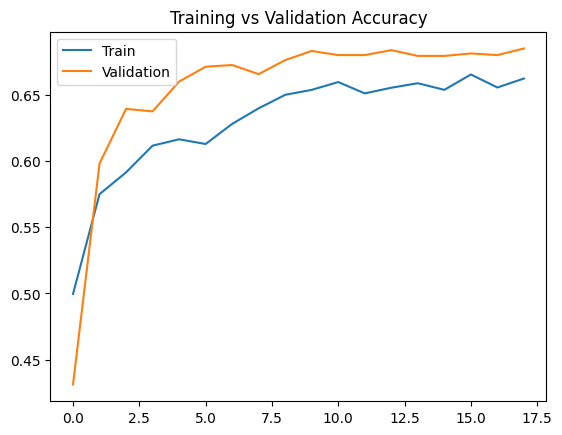

In [15]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [16]:
print("Best Validation Accuracy:", max(history.history['val_accuracy'])*100)

Best Validation Accuracy: 68.50000023841858
